# Data Analysis for water measurments
This code measure the carachteristic time $\tau$ of our temperature(time) dataset using curve_fit method. From calorimetry we can show that the solar energy flux on earth surface $\Phi$ can be estimated exposing a black body to sunlight and measuring its temperature in time. We expect an exponential $1-e^{-t/\tau}$ behavior. At the end we arrive at the usefull formula:

$$ \Phi = \frac{C \Delta_T}{A\tau}$$

with $C =$ heat cpacity, $\Delta_T = $ temperature delta (from ambient temp to final, stady state, temp), $A =$ area exposed to light and $\tau =$ characteristic time. 
## Water body
We can use for our experiment a glass of water. It's necessary, belong to the flux formula, to measure at first:
* m = mass of the water
* Area of exposition to the sun

Note that this formula refers to normal incidence of light rays, but usually this is not the case. We can make the right calculation using the opportune trigonometry, but this is not our popouse.


In [ ]:
import numpy as np
import matplotlib
matplotlib.use('TKAgg')
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

t, T1 = np.loadtxt("Directory/data.txt", unpack = True)
c = 4186 #[J/kg*K] water specific heat

m = 0.073 #kg mass of the water
A = 0.01 #m^2 area of the surface exposed to sun

C = m*c #J/K heat capacity of the water
rs = 149597870000 #solar distance in meters

fig = plt.figure('FIT Bicchiere al sole')


# If you want to cut the data uncomment the following lines. It cuts all the data with t>1500s and t<200, change the range to your needs.
'''
mask = t<1500
t = t[mask]
T1 = T1[mask]

mask1 = t>200
t = t[mask1]
T1 = T1[mask1]
'''

T = T1 + 273.15 #Kelvin

err = np.full(T.shape, 0.06) #Error on T, this is ds18b20 sensor error

# Model function
def f(t, a, b, tau):
    return a + b*(1-np.exp(-t/tau))     #exponential rise to a limit. a is the initial (ambient) temperature, b is the difference between initial and asymptotic temperature, tau is the characteristic time

p0 = [296, 3, 1000]     # Initial guess for a, b, tau
popt, pcov = curve_fit(f, t, T, sigma = err, absolute_sigma=True)   #popt contains the best fit values for a, b, tau
a_hat, b_hat, tau_hat = popt    #best fit values for a, b, tau
da, db, dtau = np.sqrt(pcov.diagonal())     #uncertainties on a, b, tau

plt.errorbar(t, T, 0.06, None, fmt='.', color = 'blue', zorder = 1)     #data with error bars

plt.plot(t, f(t, a_hat, b_hat, tau_hat), color = 'red', zorder = 2)     #best fit curve

#Figure settings
plt.grid(which = 'both', ls = 'dashed', color = 'grey')
plt.xlabel('t')
plt.ylabel('T [K]')
plt.title('FIT Bicchiere al sole')

#Print results
print(tau_hat, dtau) #secondi
print(b_hat, db)
print(a_hat, da)


flux = (C *(b_hat)) / (A * tau_hat) #Energy flux (W/m^2) on the water surface
flux_tot = flux * 4*np.pi * rs**2 #Total power emitted by the sun (W)

#Flux results
print(flux)
print(flux_tot)

plt.show()


# Steel Black Body

The following code is equivalent to the previous one, but it refers to a **steel black body**, as shown in the photo below.  

The area and mass were **estimated** using proper measurements. We expect an irradiance between **400 and 800 W/m²**, depending on the season, weather conditions, and cloud cover.  

You can check the expected results on the [PVGIS website](https://re.jrc.ec.europa.eu/pvg_tools/en/). To do so:  
* Select the option **"Daily data"**.  
* Choose the measurement location using the map on the left.  
* Select the month.  
* Under the paragraph **"On sun tracking plane"**, select both options.  
* Click **"Visualize results"**.  

A graph will then appear, similar to the one shown in the picture below.  

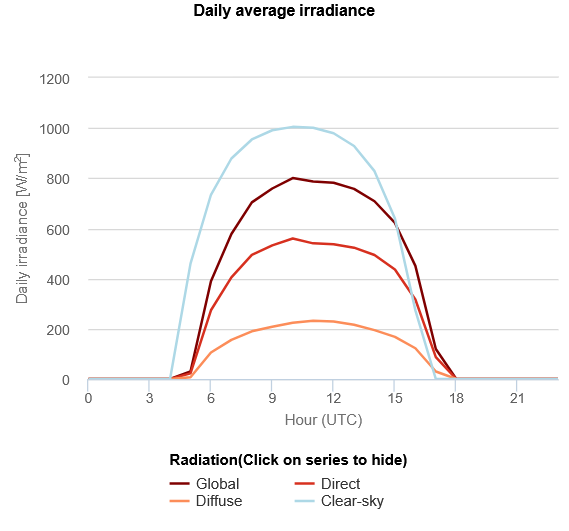

You should expect better results than with the water body. The experiment may not work, as there are several factors that we consider negligible.



In [ ]:
import numpy as np
import matplotlib
matplotlib.use('TKAgg')
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

t, T1 = np.loadtxt("Directory/Data.txt", unpack = True)
c = 460 #[J/kg*K] water specific heat

m = 0.351 #kg mass of the water
A = 0.0225 #m^2 area of the surface exposed to sun

C = m*c #J/K heat capacity of the water
rs = 149597870000 #solar distance in meters

fig = plt.figure('FIT Bicchiere al sole')


# If you want to cut the data uncomment the following lines. It cuts all the data with t>2000s and t<20, change the range to your needs. 
# The t-20 is necessary for a correct extimation of fitting parameters. You have to change in t-mask1 if you change your lower limit.
t = t-20
mask = t<2000
t = t[mask]
T1 = T1[mask]

mask1 = t>20
t = t[mask1]
T1 = T1[mask1]

T = T1 + 273.15 #Kelvin

err = np.full(T.shape, 0.06) #Error on T, this is ds18b20 sensor error

# Model function
def f(t, a, b, tau):
    return a + b*(1-np.exp(-t/tau))     #exponential rise to a limit. a is the initial (ambient) temperature, b is the difference between initial and asymptotic temperature, tau is the characteristic time

p0 = [315, 20, 1000]     # Initial guess for a, b, tau
popt, pcov = curve_fit(f, t, T, sigma = err, p0=p0, absolute_sigma=True)   #popt contains the best fit values for a, b, tau
a_hat, b_hat, tau_hat = popt    #best fit values for a, b, tau
da, db, dtau = np.sqrt(pcov.diagonal())     #uncertainties on a, b, tau

plt.errorbar(t, T, 0.06, None, fmt='.', color = 'blue', zorder = 1)     #data with error bars

plt.plot(t, f(t, a_hat, b_hat, tau_hat), color = 'red', zorder = 2)     #best fit curve

#Figure settings
plt.grid(which = 'both', ls = 'dashed', color = 'grey')
plt.xlabel('t')
plt.ylabel('T [K]')
plt.title('Pireliometro')

#Print results
print(tau_hat, dtau) #secondi
print(b_hat, db)
print(a_hat, da)


flux = (C *(b_hat)) / (A * tau_hat) #Energy flux (W/m^2) on the water surface
flux_tot = flux * 4*np.pi * rs**2 #Total power emitted by the sun (W)

#Flux results
print(flux)
print(flux_tot)

plt.show()
